In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors


import os
import scanpy as sc
import scvi
import seaborn as sns



/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndat

## Load Data

In [2]:
# Save dataframe 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_RNA_cluster_and_DNAdebrisflag.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris
atac_bc,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO


In [32]:
SADE_atac_cluster_info_subdir = os.path.join(Union_cell_subdir, "SADE_atac_cluster_info")
SADE_atac_cluster_info_file = os.path.join(SADE_atac_cluster_info_subdir, "SADE_atac_cluster_info.tsv")

SADE_atac_cluster_info = pd.read_csv(SADE_atac_cluster_info_file, sep='\t', index_col=1)

SADE_atac_cluster_info.head(2)

,barcodes,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,...,log10_total_frag,_scvi_batch,_scvi_labels,clusters_peakvi_SADE,MT%,total_RNA_UMI_log,n_genes_by_RNA_counts,N_MT_counts,leiden_RNA_scVI_unionBC,leiden_RNA_scVI_SADE
atac_barcodes,,,,,,,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,AAACAAGCAAGTTAGT-1,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,...,3.382377,0,0,6,13.120394,7.618742,1147.0,267.0,3,2.0
AAACAAGCATTTCTTC,AAACAAGCATTTCTTC-1,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,...,3.955688,0,0,9,26.166204,8.082711,1531.0,847.0,0,1.0


In [5]:
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
h5_rna_union_file = os.path.join(Union_cell_subdir, 'Union_3set_rna.h5ad')

h5_rna_union = sc.read_h5ad(h5_rna_union_file)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [6]:
h5_rna_union, h5_rna_union.shape

(AnnData object with n_obs × n_vars = 2381 × 36601
     obs: 'rna_barcodes', 'atac_barcodes', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'gene_ids', 'feature_types', 'genome',
 (2381, 36601))

In [22]:
col_list = ['atac_pass_entropy', 'atac_pass_CR', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', 'total_fragments', 'clusters_peakvi_SADE']
for col in col_list:
    h5_rna_union.obs[col] = h5_rna_union.obs['atac_barcodes'].map(SADE_atac_cluster_info[col])

In [31]:
h5_rna_union.obs['clusters_peakvi_SADE'].value_counts()

clusters_peakvi_SADE
0.0    390
1.0    302
2.0    228
3.0    215
4.0    207
5.0    187
6.0    179
7.0    170
8.0    112
9.0    108
Name: count, dtype: int64

# Now only subset BCs SADE called cells

In [24]:
h5_rna_SADE = h5_rna_union[h5_rna_union.obs['atac_pass_entropy'] == True].copy()
h5_rna_SADE.shape # 2101 -3 (that do not have RNA-info)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


(2098, 36601)

In [ ]:
sc.pp.filter_genes(h5_rna_SADE, min_counts=3)
h5_rna_SADE.raw = h5_rna_SADE # keep full dimension safe
h5_rna_SADE.layers['counts'] = h5_rna_SADE.X
sc.pp.highly_variable_genes(
h5_rna_SADE,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)


h5_rna_SADE.layers['log1p_counts'] = np.log1p(h5_rna_SADE.X)
h5_rna_SADE.layers['cpm'] = sc.pp.normalize_total(h5_rna_SADE, target_sum=1e4, inplace=False)['X']
h5_rna_SADE.layers['log1p_cpm'] = np.log1p(h5_rna_SADE.layers['cpm'])

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [26]:
SCVI_LATENT_KEY = "RNA_scVI_SADE"
SCVI_CLUSTERS_KEY = "leiden_RNA_scVI_SADE"


# scvi.settings.seed = 0
# scvi.model.SCVI.setup_anndata(h5_rna_SADE, layer="counts")
# vae = scvi.model.SCVI(h5_rna_SADE, n_layers=3, n_latent=30, gene_likelihood="nb")
# vae.train()

# h5_rna_SADE.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()
# print("Save integrated samples into .h5ad file and trained SCVI model into subfolder\n") 
# vae_model_folder=os.path.join(entropy_dir, "_cmpSC_RNA_scvi_model")
# vae.save(vae_model_folder, overwrite=True)

vae_model_folder=os.path.join(entropy_dir, "_cmpSC_RNA_scvi_model")
vae = scvi.model.SCVI.load(vae_model_folder, adata=h5_rna_SADE)
h5_rna_SADE.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()

# clustering using scVI latent representation via Leiden
resolution = 0.5
sc.pp.neighbors(h5_rna_SADE, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(h5_rna_SADE, min_dist=0.5)
sc.tl.leiden(h5_rna_SADE, key_added=SCVI_CLUSTERS_KEY, resolution=resolution )

INFO     File /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_cmpSC_RNA_scvi_model/model.pt already   
         downloaded                                                                                                


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_

In [33]:
h5_rna_SADE.obs['log_n_genes_by_RNA'] = np.log10(h5_rna_SADE.obs['n_genes_by_RNA_counts'] )
h5_rna_SADE.obs['log_total_frag'] = np.log10(h5_rna_SADE.obs['total_fragments'] )
h5_rna_SADE.obs['clusters_peakvi_SADE'] = h5_rna_SADE.obs['clusters_peakvi_SADE'].astype(str)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


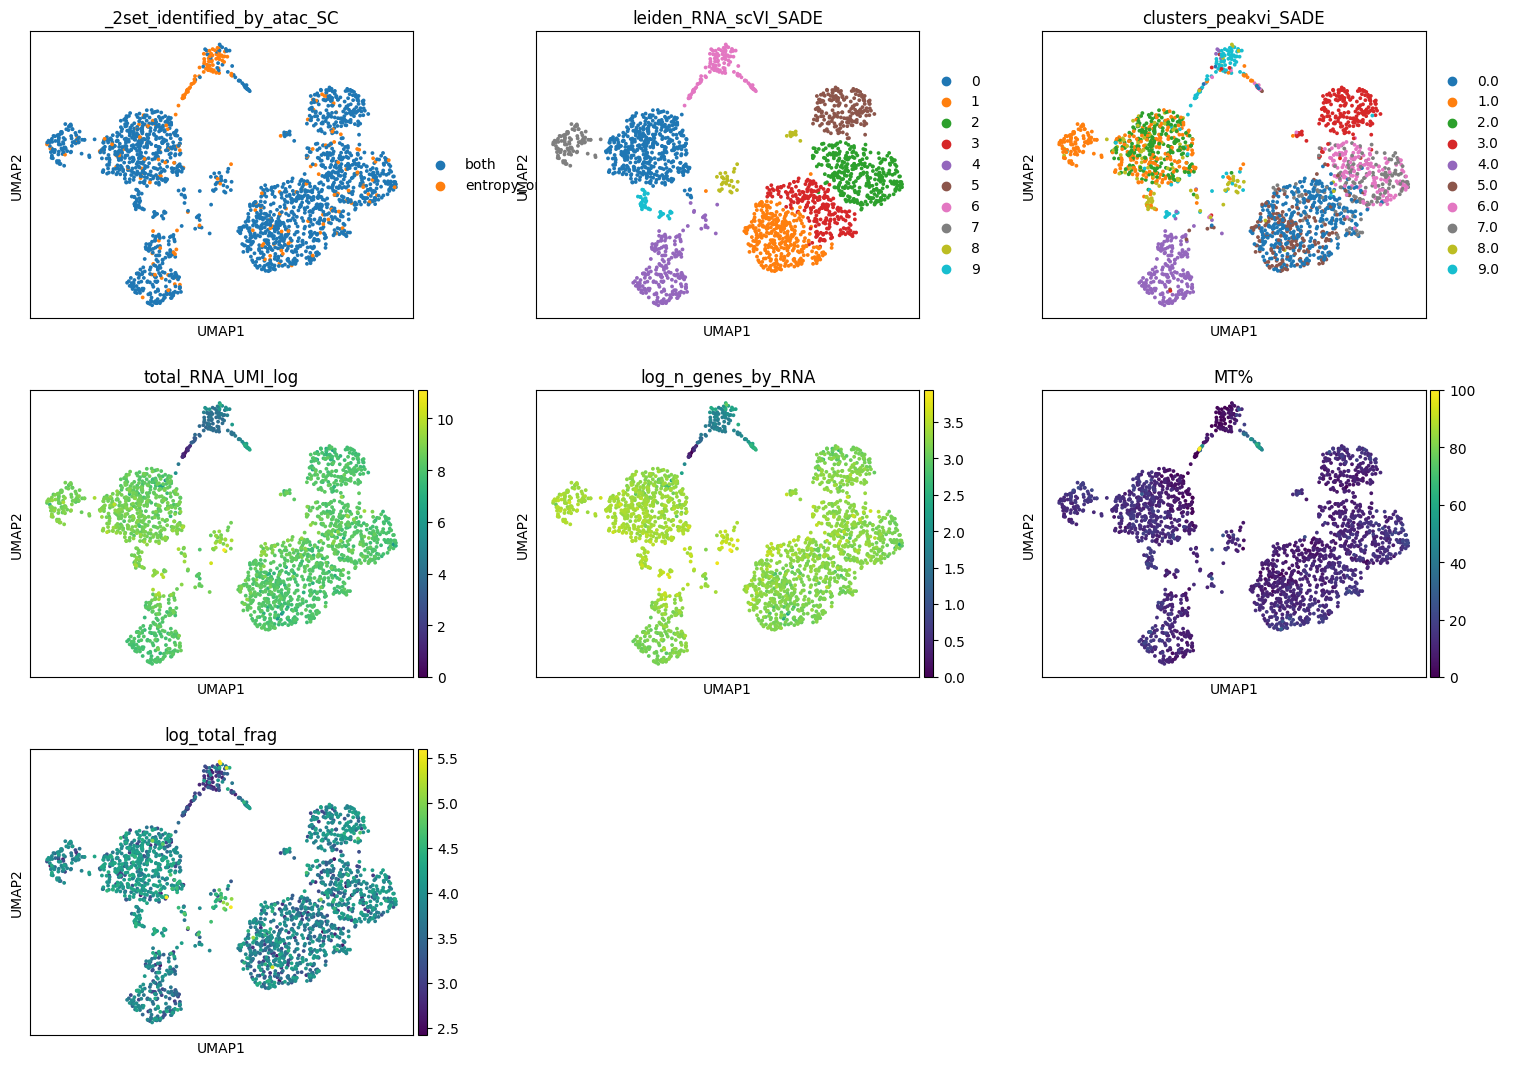

In [34]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna_SADE, color=['_2set_identified_by_atac_SC', 'leiden_RNA_scVI_SADE']+ 
               ['clusters_peakvi_SADE'] + 
               ['total_RNA_UMI_log', 'log_n_genes_by_RNA',  'MT%','log_total_frag'], wspace=0.2, size=30, ncols=3)

In [35]:
h5_rna_SADE.var_names_make_unique("-")

SADE_special_cluster = h5_rna_SADE.obs['clusters_peakvi_SADE'].unique().tolist()


DE_rna_clusters = {}
for cluster in SADE_special_cluster:
    DE_rna_clusters[cluster] =  vae.differential_expression(h5_rna_SADE, groupby='clusters_peakvi_SADE', group1=cluster)


# save DE results
DE_dir = os.path.join(SADE_atac_cluster_info_subdir, 'corresponding_rna_DE_results')
if not os.path.exists(DE_dir):
    os.makedirs(DE_dir)

save_cols = ['lfc_mean', 'neg_log10_pval', 'is_de_fdr_0.05', 'proba_de',  'proba_not_de', 'comparison', 'raw_mean1', 'raw_mean2', 'group1', 'group2']
for c in SADE_special_cluster:
    DE_rna_clusters[c]['neg_log10_pval'] = -np.log10(DE_rna_clusters[c]['proba_not_de'])
    _ = DE_rna_clusters[c].loc[(DE_rna_clusters[c]['is_de_fdr_0.05']) & (DE_rna_clusters[c]['lfc_mean'] > 0.) ].sort_values('lfc_mean', ascending=False)
    _[save_cols].to_csv(os.path.join(DE_dir, f'SADE_c_{c}_Up.tsv'), sep='\t')
    _ = DE_rna_clusters[c].loc[(DE_rna_clusters[c]['is_de_fdr_0.05']) & (DE_rna_clusters[c]['lfc_mean'] < 0.) ].sort_values('lfc_mean', ascending=True)
    _[save_cols].to_csv(os.path.join(DE_dir, f'SADE_c_{c}_Down.tsv'), sep='\t')

DE...: 100%|██████████| 1/1 [00:03<00:00,  3.13s/it]

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/_utils.py:192: RuntimeWarning: divide by zero encountered in divide
  scaling_factor = 1 / np.asarray(data.sum(axis=1)).ravel().reshape(-1, 1)



DE...: 100%|██████████| 1/1 [00:02<00:00,  2.96s/it]


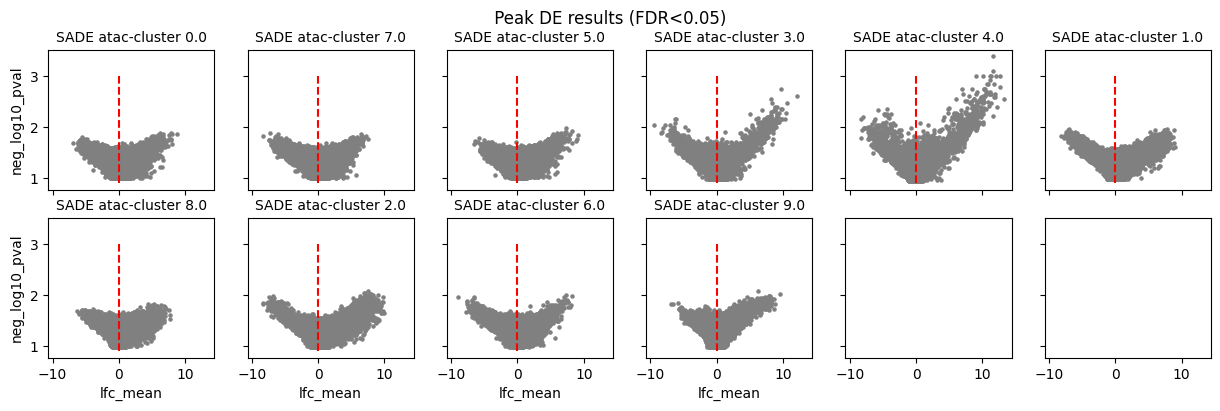

In [38]:
fig, axes = plt.subplots(2, 6,  figsize=(15,4),  sharex=True, sharey=True)
axes = axes.flatten()

for i, cluster in enumerate(SADE_special_cluster):
    ax = axes[i]
    DE_rna_clusters[cluster].loc[(DE_rna_clusters[cluster]['is_de_fdr_0.05']) ].plot.scatter(x='lfc_mean', y='neg_log10_pval', ax=ax, title=f'rna cluster {cluster}', s = 5, c='grey' )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=3, linestyle='--')
    ax.set_title(f'SADE atac-cluster {cluster}', fontsize=10)

plt.suptitle(' Peak DE results (FDR<0.05) ', fontsize=12)
plt.show()

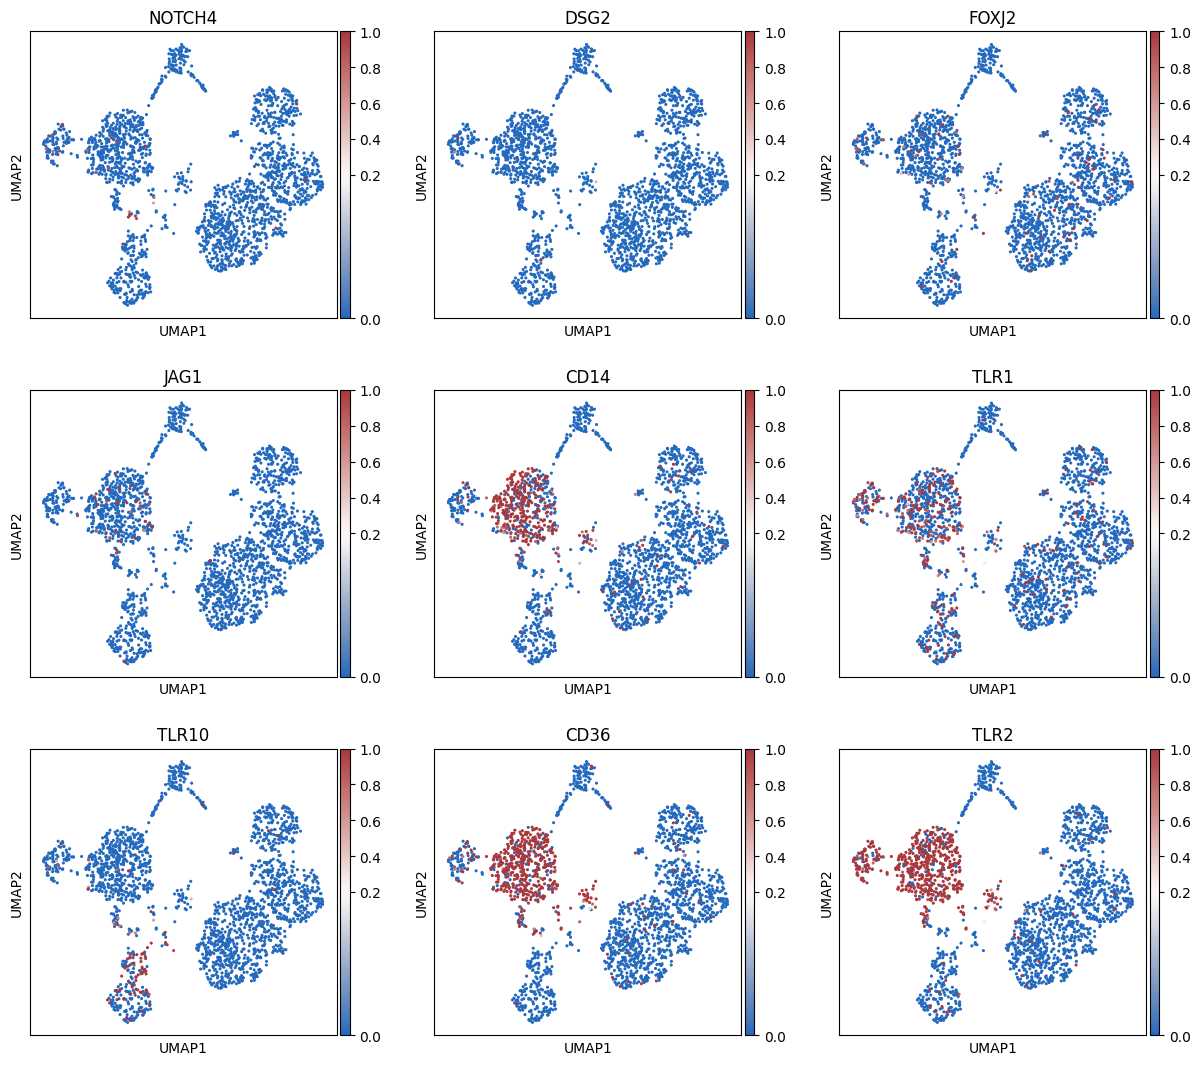

In [89]:
genes = ['NOTCH4', 'DSG2', 'FOXJ2', 'JAG1', 'CD14', 'TLR1', 'TLR10', 'CD36', 'TLR2'] # Up
# genes =['STAP1', 'CD81', 'LCK', 'CD28', 'BCL10', 'ADA', 'CD226', 'IL7R'] # Down
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(h5_rna_SADE, color=genes, wspace=0.2, size=20, ncols=3, layer='log1p_cpm', color_map='vlag', vmin=0, vmax=1, vcenter=0.2)

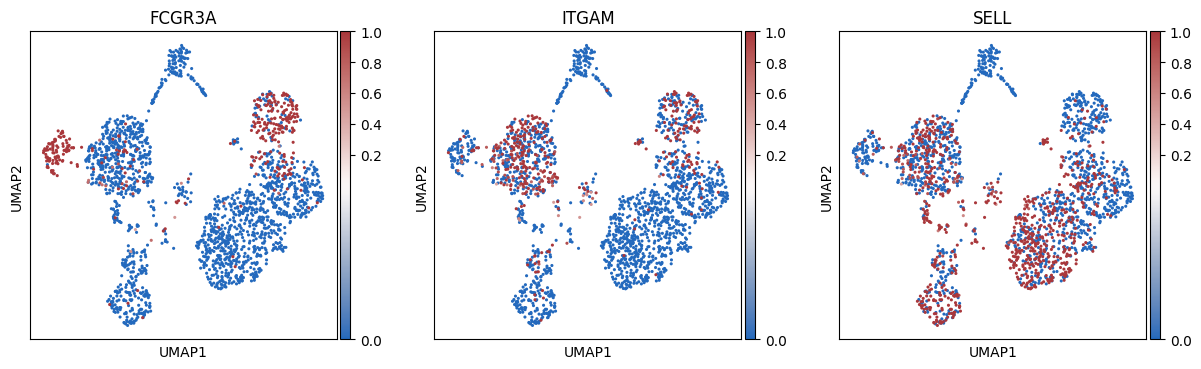

In [112]:
genes = ['FCGR3A', 'ITGAM', 'SELL']
# genes =['STAP1', 'CD81', 'LCK', 'CD28', 'BCL10', 'ADA', 'CD226', 'IL7R'] # Down
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(h5_rna_SADE, color=genes, wspace=0.2, size=20, ncols=3, layer='log1p_cpm', color_map='vlag', vmin=0., vmax=1, vcenter=0.0005)

In [138]:
h5_rna_SADE.obs.loc[(h5_rna_SADE.obs['clusters_peakvi_SADE'] == '9.0') & (h5_rna_SADE.obs['total_RNA_UMI']  < 100), 'sade_c9_lowRNA' ] = 'lowRNA'


h5_rna_SADE.obs.loc[(h5_rna_SADE.obs['clusters_peakvi_SADE'] == '9.0') & (h5_rna_SADE.obs['total_RNA_UMI']  >= 100), 'sade_c9_lowRNA' ] = 'okRNA'

h5_rna_SADE.obs['sade_c9_lowRNA'].value_counts()

sade_c9_lowRNA
lowRNA    65
okRNA     43
Name: count, dtype: int64

{'bodies': [<matplotlib.collections.PolyCollection at 0x7dacecf8a390>,
 'cmeans': <matplotlib.collections.LineCollection at 0x7dacec8fa2d0>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x7dacecb74210>,
 'cmins': <matplotlib.collections.LineCollection at 0x7dacf4128ed0>,
 'cbars': <matplotlib.collections.LineCollection at 0x7dadfc216650>}

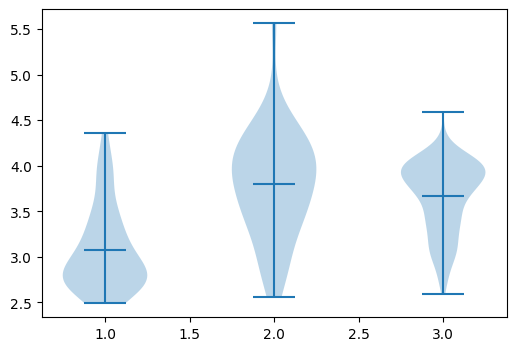

In [145]:
fig, ax = plt.subplots(figsize=(6,4))

total_frag_ls = [h5_rna_SADE.obs.loc[h5_rna_SADE.obs['sade_c9_lowRNA'] == 'lowRNA']['log_total_frag'],
              h5_rna_SADE.obs.loc[h5_rna_SADE.obs['sade_c9_lowRNA'] == 'okRNA']['log_total_frag'], 
              h5_rna_SADE.obs.loc[h5_rna_SADE.obs['clusters_peakvi_SADE'] == '1.0']['log_total_frag']
              
              ]
ax.violinplot(total_frag_ls,  positions=[1, 2, 3], showmeans=True)

In [146]:
h5_rna_SADE.obs.groupby(['_2set_identified_by_atac_SC', 'sade_c9_lowRNA']).size().unstack()

/tmp/ipykernel_3710903/353305121.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_rna_SADE.obs.groupby(['_2set_identified_by_atac_SC', 'sade_c9_lowRNA']).size().unstack()


sade_c9_lowRNA,lowRNA,okRNA
_2set_identified_by_atac_SC,,
both,6,34
entropy_only,59,9


Text(0, 0.5, 'Total Fragments')

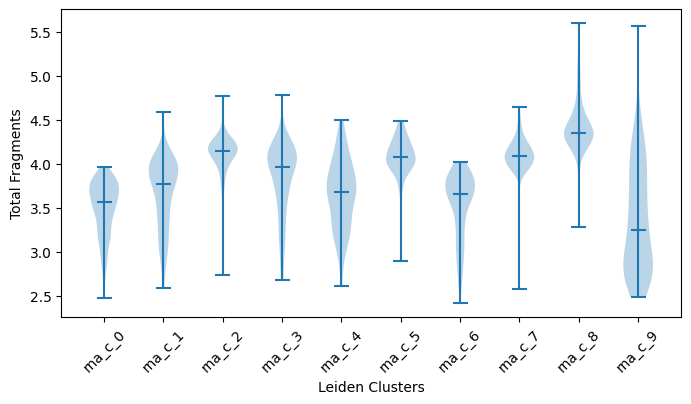

In [148]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

x_positions = h5_rna_SADE.obs['clusters_peakvi_SADE'].cat.codes.unique()
atac_read_depth = [h5_rna_SADE.obs['total_fragments'].apply(lambda x: np.log10(x + 1)).loc[
    (h5_rna_SADE.obs['clusters_peakvi_SADE'].cat.codes == cluster) 
    ] for cluster in x_positions]
ax.violinplot(atac_read_depth, positions=x_positions, showmeans=False, showmedians=True)
ax.set_xticks(x_positions)
ax.set_xticklabels(['rna_c_' + str(i) for i in x_positions], rotation=45)
ax.set_xlabel('Leiden Clusters')
ax.set_ylabel('Total Fragments')

Text(0, 0.5, 'Total Fragments')

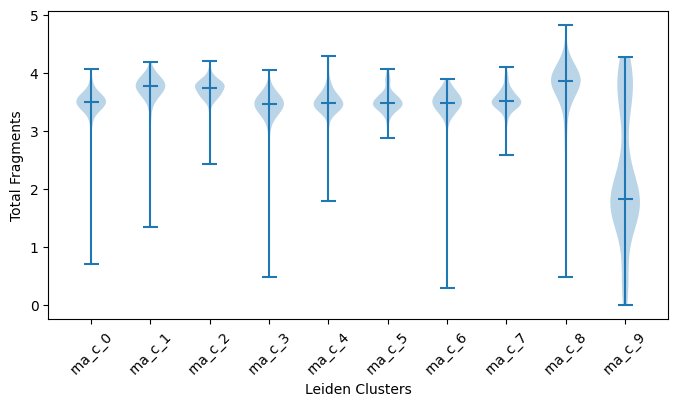

In [149]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

x_positions = h5_rna_SADE.obs['clusters_peakvi_SADE'].cat.codes.unique()
atac_read_depth = [h5_rna_SADE.obs['total_RNA_UMI'].apply(lambda x: np.log10(x + 1)).loc[
    (h5_rna_SADE.obs['clusters_peakvi_SADE'].cat.codes == cluster) 
    ] for cluster in x_positions]
ax.violinplot(atac_read_depth, positions=x_positions, showmeans=False, showmedians=True)
ax.set_xticks(x_positions)
ax.set_xticklabels(['rna_c_' + str(i) for i in x_positions], rotation=45)
ax.set_xlabel('Leiden Clusters')
ax.set_ylabel('Total Fragments')

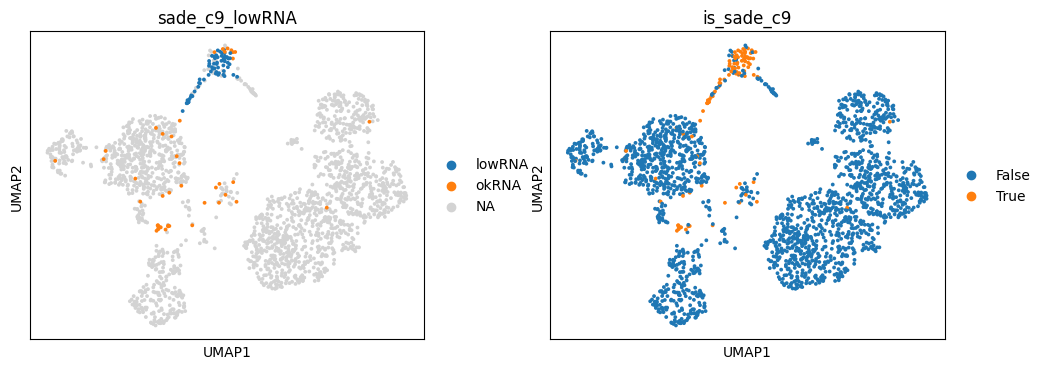

In [ ]:

h5_rna_SADE.obs['is_sade_c9'] = h5_rna_SADE.obs['clusters_peakvi_SADE'] == '9.0'

with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna_SADE, color=['sade_c9_lowRNA', 'is_sade_c9'], wspace=0.2, size=30, ncols=3)

In [ ]:
h5_rna_SADE.obs.loc[(h5_rna_SADE.obs['clusters_peakvi_SADE'] == '9.0') & (h5_rna_SADE.obs['leiden_RNA_scVI_SADE'] == '6')]['total_RNA_UMI'].describe(),  \
    
h5_rna_SADE.obs.loc[(h5_rna_SADE.obs['clusters_peakvi_SADE'] == '9.0') & (h5_rna_SADE.obs['leiden_RNA_scVI_SADE'] == '6')]['total_fragments'].describe()

count       73.000000
mean      3257.493151
std       5371.707948
min        310.000000
25%        579.000000
50%       1005.000000
75%       3055.000000
max      23211.000000
Name: total_fragments, dtype: float64

In [154]:
h5_rna_SADE.obs.loc[(h5_rna_SADE.obs['clusters_peakvi_SADE'] == '9.0') & (h5_rna_SADE.obs['leiden_RNA_scVI_SADE'] == '6') & (h5_rna_SADE.obs['_2set_identified_by_atac_SC']  =='both')]['total_fragments'].describe()

count       11.000000
mean     12942.181818
std       7476.405043
min       3257.000000
25%       7818.500000
50%       9477.000000
75%      20381.500000
max      23211.000000
Name: total_fragments, dtype: float64

In [163]:
h5_rna_SADE.obs.loc[(h5_rna_SADE.obs['clusters_peakvi_SADE'] == '9.0') & (h5_rna_SADE.obs['leiden_RNA_scVI_SADE'] == '6')].groupby('_2set_identified_by_atac_SC').sum('total_fragments')

/tmp/ipykernel_3710903/2874038883.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_rna_SADE.obs.loc[(h5_rna_SADE.obs['clusters_peakvi_SADE'] == '9.0') & (h5_rna_SADE.obs['leiden_RNA_scVI_SADE'] == '6')].groupby('_2set_identified_by_atac_SC').sum('total_fragments')


,total_RNA_UMI,total_RNA_UMI_log,n_genes_by_RNA_counts,N_MT_counts,MT%,log10_total_frag,total_fragments,_scvi_batch,_scvi_labels,log_n_genes_by_RNA,log_total_frag,_scvi_raw_norm_scaling,amulet_doublet_atac,is_sade_c9
_2set_identified_by_atac_SC,,,,,,,,,,,,,,
both,1492.0,50.672218,1310,107.0,77.190613,44.426107,142364.0,0,0,21.471519,44.426107,1557.915649,0,11
entropy_only,3143.0,212.523651,2856,127.0,394.208069,185.884429,95433.0,0,0,-inf,185.884429,inf,0,62


In [155]:
h5_rna_SADE.obs.loc[(h5_rna_SADE.obs['clusters_peakvi_SADE'] == '9.0') & (h5_rna_SADE.obs['leiden_RNA_scVI_SADE'] == '6') & (h5_rna_SADE.obs['_2set_identified_by_atac_SC']  =='entropy_only')]['total_fragments'].describe()

count       62.000000
mean      1539.241935
std       2231.805339
min        310.000000
25%        530.250000
50%        764.000000
75%       1685.250000
max      15682.000000
Name: total_fragments, dtype: float64

In [157]:
h5_rna_SADE.obs.loc[(h5_rna_SADE.obs['clusters_peakvi_SADE'] == '9.0') & (h5_rna_SADE.obs['leiden_RNA_scVI_SADE'] == '6') & (h5_rna_SADE.obs['_2set_identified_by_atac_SC']  =='entropy_only')]['total_fragments'].sum()

95433.0

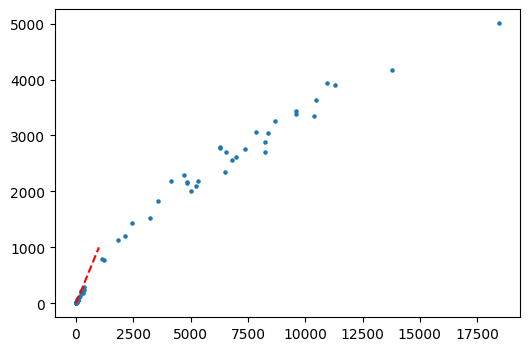

In [128]:
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x=h5_rna_SADE.obs.loc[h5_rna_SADE.obs['clusters_peakvi_SADE'] == '9.0']['total_RNA_UMI'],
              y=h5_rna_SADE.obs.loc[h5_rna_SADE.obs['clusters_peakvi_SADE'] == '9.0']['n_genes_by_RNA_counts'], s=5)
ax.plot([0, 1000], [0, 1000], color='red', linestyle='--')

In [119]:
h5_rna_SADE.obs.columns

Index(['rna_barcodes', 'atac_barcodes', 'total_RNA_UMI', 'total_RNA_UMI_log',
       'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%', 'atac_pass_entropy',
       'atac_pass_CR', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC',
       '_2set_identified_by_atac_ST', 'log10_total_frag',
       'clusters_peakvi_SADE', 'total_fragments', '_scvi_batch',
       '_scvi_labels', 'leiden_RNA_scVI_SADE', 'log_n_genes_by_RNA',
       'log_total_frag', '_scvi_raw_norm_scaling', 'amulet_doublet_atac'],
      dtype='object')